# Signal B: Short-Horizon Cross-Sectional Momentum on Large Caps

## Parameters

- **In-Sample (IS)**: 2020-03-01 to 2023-12-31
- **Out-of-Sample (OOS)**: 2024-01-01 to Rest of Sample
- **Universe**: Top 7 to 20 Large Cap Coins in Our Current Universe by trailing 30d dvol

## Hypothesis

Cross-sectional momentum should emerge at horizons in the 1 day to 2 week range on large caps.


## Set-Up

In [19]:
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import time
from collections import Counter
import os
import pickle
import matplotlib.pyplot as plt

# NOTE: Either launch the jupyter notebook in the project directory or run chdir.

os.chdir('/Users/muditlam/Desktop/PythonJupyterCode/cryptoStatArbProject')

from quantlib import (
    rank_demean_normalize, compute_turnover, apply_costs,
    get_stats, factor_regression, drawdown,
    BARS_PER_YEAR_4H, DEFAULT_COST_BPS_MARKET,
)

print("Working directory:", os.getcwd())

PROJECT_DIR = os.path.dirname(os.path.abspath('DataPipeline.ipynb'))
PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'binance_ohlcv_panel_4h.pkl')

print(PANEL_DATA_PATH)
os.makedirs(os.path.dirname(PANEL_DATA_PATH), exist_ok=True)
print(f"Save path: {PANEL_DATA_PATH}")

FREQ = '4h'
START_TS = '2019-01-01'

panels = pickle.load(open(PANEL_DATA_PATH, 'rb'))

px = panels['px']
ret = panels['ret']
dvol = panels['dvol']
taker_buy_dvol = panels['taker_buy_dvol']
num_trades = panels['num_trades']
high_px = panels['high_px']
low_px = panels['low_px']
close_px = panels['close_px']
universe = panels['universe']
universe_daily = panels['universe_daily']
universe_monthly = panels['universe_monthly']
candidate_symbols = panels['candidate_symbols']

print(f"Loaded pickle. px: {px.shape}, ret: {ret.shape})")


Working directory: /Users/muditlam/Desktop/PythonJupyterCode/classProject
/Users/muditlam/Desktop/PythonJupyterCode/classProject/data/binance_ohlcv_panel_4h.pkl
Save path: /Users/muditlam/Desktop/PythonJupyterCode/classProject/data/binance_ohlcv_panel_4h.pkl
Loaded pickle. px: (14417, 193), ret: (14417, 193))


## Knobs and Samples

In [20]:
IS_START, IS_END = '2020-03-01', '2023-12-31'
OOS_START = '2024-01-01'
UNIVERSE_MIN_SIZE, UNIVERSE_MAX_SIZE = 7, 20
HORIZONS_IN_BARS = [1, 6, 18, 42, 84, 168] # 4 hours, 1 day, 3 days, 1 week, 2 weeks, 1 month

ret_is = ret.loc[IS_START:IS_END]
universe_is = universe[IS_START:IS_END]
dvol_is = dvol.loc[IS_START:IS_END]
dvol_is_masked = dvol_is.where(universe_is)
dvol_30day_trailing = dvol_is_masked.rolling(180, min_periods=90).mean()
ranked_dvol = dvol_30day_trailing.rank(axis=1,ascending=False)
universe_top20_is = universe_is & (ranked_dvol <= UNIVERSE_MAX_SIZE)

## Research

Sweep six lookback horizons crossed with three signal directions (reversal, momentum, momentum-skip-1). Top-20 universe, per-bar rebalance, IS only, gross Sharpe. No costs and no spec commitment yet. The point is to find where the cross-sectional return effect changes sign and at what horizon momentum is strongest.

In [21]:
result = {
    'reversal': [],
    'momentum': [],
    'momentum_shifted': []
}
for horizon in HORIZONS_IN_BARS:
    trailing_horizon = ret_is.rolling(horizon, min_periods=horizon).sum()

    reversal_signal = -1 * trailing_horizon
    momentum_signal = trailing_horizon
    momentum_shifted_signal = trailing_horizon.shift(1)

    rebalance_mask = pd.Series(
        (np.arange(len(ret_is)) % 18) == 0,
        index=ret_is.index
        )

    reversal_weights = rank_demean_normalize(reversal_signal, universe=universe_top20_is).shift(1)
    momentum_weights = rank_demean_normalize(momentum_signal, universe=universe_top20_is).shift(1)
    momentum_shifted_weights = rank_demean_normalize(momentum_shifted_signal, universe=universe_top20_is).shift(1)

    ret_reversal = (reversal_weights * ret_is).sum(axis=1)
    ret_momentum = (momentum_weights * ret_is).sum(axis=1)
    ret_momentum_shifted = (momentum_shifted_weights * ret_is).sum(axis=1)

    result['reversal'].append(get_stats(ret_reversal)['sharpe'])
    result['momentum'].append(get_stats(ret_momentum)['sharpe'])
    result['momentum_shifted'].append(get_stats(ret_momentum_shifted)['sharpe'])

result_df = pd.DataFrame(result, index=HORIZONS_IN_BARS)
print(result_df)

     reversal  momentum  momentum_shifted
1    5.993553 -5.993553          0.164166
6    1.808803 -1.808803          0.994530
18   0.225622 -0.225622          1.040776
42  -0.973936  0.973936          1.862783
84  -0.496207  0.496207          1.150317
168 -0.910947  0.910947          1.353962


## Research Interpretation

**Setup:** 6 lookback horizons × 3 directions (reversal, momentum, momentum-skip-1), top-20 universe, per-bar rebalance, IS only (2020-03-01 to 2023-12-31), gross Sharpe, no costs yet.

**What I see:**

- **Reversal dies between 3 days and 1 week.** Reversal Sharpe is +5.99 at H=1 (microstructure), decays to +0.23 at H=18, and flips negative by H=42. The crossover is around the 3-day mark. This matches HW8's finding that reversal dominates intraday and dies near the 1-day boundary, extended here to show reversal is actually losing by 1 week on our universe. The H=1 result is ~pure microstructure reversal (bid-ask bounce, market-maker rebalancing) and will not survive costs, so it is not pursued as Signal B.

- **Momentum becomes positive starting at 1 week.** Pure momentum (no skip) flips from negative to +0.97 at H=42, peaks there, and weakens at longer horizons (+0.50 at 2w, +0.91 at 4w). Cross-sectional momentum on crypto large caps peaks at ~1 week, not at the 3–12 month horizons seen in equity momentum. 
- **Skipping the most recent bar materially strengthens momentum.** At H=42, momentum Sharpe rises from +0.97 (no skip) to +1.86 (skip-1) — roughly double. 
- **The winning cell is H=42 momentum-skip-1, gross Sharpe +1.86.** This is the candidate spec for Phase 2 cost-aware evaluation. Lookback horizon = 1 week (42 bars), signal = +sum(r_{t-42:t-1}), universe = top-20 by trailing 30d dvol, rebalance = per-bar.

**What remains open:**

- **Cost sensitivity is unknown.** Per-bar rebalance on a 42-bar window should be relatively smooth, but +skip-1 momentum may have higher turnover than Signal C's +reversal at the same horizon. Phase 2 will compute turnover and net Sharpe at 20bps.
- **Rebalance cadence not yet tested.** Per-bar rebalance is the default; slower cadences (daily, 3d, weekly) may give better net Sharpe by reducing turnover. Phase 2 will test.
- **Universe size held fixed at top-20.** If net Sharpe is borderline, we will sensitivity-check top-10 and top-30 as a robustness step, but not as a tuning step.


## Per-4H Rebalance

Cost-aware evaluation of the winning research cell (H=42, momentum-skip-1) at the fastest possible cadence. Net Sharpe at 20bps tells us how much of the gross edge is eaten by turnover.

In [22]:
trail_42 = ret_is.rolling(42, min_periods=42).sum()
signal_42_skip_1 = trail_42.shift(1)

weights_per_bar = rank_demean_normalize(signal_42_skip_1, universe=universe_top20_is)
gross_ret_per_bar = (weights_per_bar.shift(1) * ret_is).sum(axis=1)

turnover_per_bar = compute_turnover(weights_per_bar)
net_ret_per_bar = apply_costs(gross_ret_per_bar, turnover_per_bar, cost_bps=20)

stats_per_bar = get_stats(net_ret_per_bar)
print(stats_per_bar)
print(turnover_per_bar.mean())
print(get_stats(gross_ret_per_bar))

ret_ann      -0.501863
vol_ann       0.296535
sharpe       -1.692428
max_dd       -0.928226
n_obs      8406.000000
dtype: float64
0.24058062989671863
ret_ann       0.551880
vol_ann       0.296266
sharpe        1.862783
max_dd       -0.300601
n_obs      8406.000000
dtype: float64


## Per-3Day Rebalance

Re-evaluate the same signal but only update weights every 18 bars (3 days). The weights between rebalance points are forward-filled. This reduces turnover, which should lift net Sharpe if the signal has persistence.

In [23]:
rebalance_mask = pd.Series(
    (np.arange(len(ret_is)) % 18) == 0,
    index=ret_is.index,
)
print(f"count: {rebalance_mask.count()}, sum: {rebalance_mask.sum()}")
rebalance_mask

count: 8406, sum: 467


2020-03-01 00:00:00     True
2020-03-01 04:00:00    False
2020-03-01 08:00:00    False
2020-03-01 12:00:00    False
2020-03-01 16:00:00    False
                       ...  
2023-12-31 04:00:00    False
2023-12-31 08:00:00    False
2023-12-31 12:00:00    False
2023-12-31 16:00:00    False
2023-12-31 20:00:00    False
Freq: 4h, Length: 8406, dtype: bool

In [24]:
weights_per_day = weights_per_bar.where(rebalance_mask, axis=0).ffill().fillna(0)
gross_ret_per_day = (weights_per_day.shift(1) * ret_is).sum(axis=1)
turnover_per_day = compute_turnover(weights_per_day)
net_ret_per_day = apply_costs(gross_ret_per_day, turnover_per_day, cost_bps=20)
stats_per_day = get_stats(net_ret_per_day)
print(stats_per_day)
print(turnover_per_day.mean())
print(get_stats(gross_ret_per_day))

ret_ann       0.072207
vol_ann       0.272428
sharpe        0.265051
max_dd       -0.501591
n_obs      8406.000000
dtype: float64
0.04774445735304547
ret_ann       0.281328
vol_ann       0.271659
sharpe        1.035594
max_dd       -0.382966
n_obs      8406.000000
dtype: float64


## Committing Final Results for OOS Sample and Performance Evaluation

1. 20 size Universe
2. 3 Day rebalance
3. 42 Hour look-back formation window

In [25]:
ret_oos = ret.loc[OOS_START:]
universe_oos = universe[OOS_START:]
dvol_oos = dvol.loc[OOS_START:]
dvol_oos_masked = dvol_oos.where(universe_oos)
dvol_30day_trailing_oos = dvol_oos_masked.rolling(180, min_periods=90).mean()
ranked_dvol_oos = dvol_30day_trailing_oos.rank(axis=1,ascending=False)
universe_top20_oos = universe_oos & (ranked_dvol_oos <= UNIVERSE_MAX_SIZE)

In [26]:
dvol_masked = dvol.where(universe)
dvol_30day_trailing_full = dvol_masked.rolling(180, min_periods=90).mean()
ranked_dvol_full = dvol_30day_trailing_full.rank(axis=1,ascending=False)
universe_top20 = universe & (ranked_dvol_full <= UNIVERSE_MAX_SIZE)

In [27]:
print(f"IS top-20 universe size per bar: {universe_top20_is.sum(axis=1).describe()[['mean','min','max']].to_dict()}")
print(f"OOS top-20 universe size per bar: {universe_top20_oos.sum(axis=1).describe()[['mean','min','max']].to_dict()}")
print(f"Full top-20 universe size per bar: {universe_top20.sum(axis=1).describe()[['mean','min','max']].to_dict()}")

IS top-20 universe size per bar: {'mean': 18.63990007137759, 'min': 0.0, 'max': 20.0}
OOS top-20 universe size per bar: {'mean': 19.64773401939442, 'min': 0.0, 'max': 20.0}
Full top-20 universe size per bar: {'mean': 17.877991260317682, 'min': 0.0, 'max': 20.0}


## Committed Signal B
Universe: top-20 by trailing 30d dvol (monthly-rebalanced top-50 -> top-20)

Horizon: 42 bars (1 week) trailing return, momentum (positive sign), skip-1

Rebalance: every 18 bars (3 days)

T-Cost: 20 bps market, applied as 20bps * turnover per bar

In [28]:
H = 42
REBALANCE_EVERY = 18  # 3 days at 4h bars

trail_42_full = ret.rolling(H, min_periods=H).sum()
signal_b_full = trail_42_full.shift(1)   # skip-1: use returns through t-1

weights_perbar_full = rank_demean_normalize(signal_b_full, universe=universe_top20)

rebalance_mask_full = pd.Series(
    (np.arange(len(ret)) % REBALANCE_EVERY) == 0,
    index=ret.index,
)

weights_b_full = (
    weights_perbar_full
    .where(rebalance_mask_full, axis=0)
    .ffill()
    .fillna(0)
)

gross_ret_b_full = (weights_b_full.shift(1) * ret).sum(axis=1)

turnover_b_full = compute_turnover(weights_b_full)

net_ret_b_full = apply_costs(gross_ret_b_full, turnover_b_full, cost_bps=20)

print(f"Full-panel strategy built.")
print(f"  Weights shape: {weights_b_full.shape}")
print(f"  Signal-valid bars: {weights_b_full.abs().sum(axis=1).gt(0).sum()}")
print(f"  Mean turnover / bar: {turnover_b_full.mean():.4f}")


Full-panel strategy built.
  Weights shape: (14417, 193)
  Signal-valid bars: 13355
  Mean turnover / bar: 0.0458


### Stats by window

Slice the full-panel return series into IS, OOS, and full windows and report gross / net Sharpe, drawdown, and turnover. The IS row is the one I committed to. OOS is the holdout check. Full is for context only.

In [29]:
# Slice the full-panel return series into the three reporting windows
def slice_window(s, start, end=None):
    return s.loc[start:end] if end else s.loc[start:]

# Signal-valid starts when trail_42 has at least 42 bars of data; safe to start at IS_START
net_is   = slice_window(net_ret_b_full,   IS_START,  IS_END)
gross_is = slice_window(gross_ret_b_full, IS_START,  IS_END)
turn_is  = slice_window(turnover_b_full,  IS_START,  IS_END)

net_oos   = slice_window(net_ret_b_full,   OOS_START)
gross_oos = slice_window(gross_ret_b_full, OOS_START)
turn_oos  = slice_window(turnover_b_full,  OOS_START)

net_full   = slice_window(net_ret_b_full,   IS_START)
gross_full = slice_window(gross_ret_b_full, IS_START)
turn_full  = slice_window(turnover_b_full,  IS_START)

# Stats table
rows = []
for label, gross, net, turn in [
    ('Full', gross_full, net_full, turn_full),
    ('IS',   gross_is,   net_is,   turn_is),
    ('OOS',  gross_oos,  net_oos,  turn_oos),
]:
    g = get_stats(gross, bars_per_year=BARS_PER_YEAR_4H)
    n = get_stats(net,   bars_per_year=BARS_PER_YEAR_4H)
    rows.append({
        'window': label,
        'n_obs': int(n['n_obs']),
        'gross_ret_ann': g['ret_ann'],
        'gross_vol_ann': g['vol_ann'],
        'gross_sharpe': g['sharpe'],
        'net_ret_ann': n['ret_ann'],
        'net_vol_ann': n['vol_ann'],
        'net_sharpe': n['sharpe'],
        'net_max_dd': n['max_dd'],
        'mean_turnover_per_bar': turn.mean(),
    })

stats_table = pd.DataFrame(rows).set_index('window')
print(stats_table.round(3))


        n_obs  gross_ret_ann  gross_vol_ann  gross_sharpe  net_ret_ann  \
window                                                                   
Full    13459          0.336          0.263         1.274        0.121   
IS       8406          0.427          0.270         1.579        0.215   
OOS      5053          0.183          0.251         0.730       -0.036   

        net_vol_ann  net_sharpe  net_max_dd  mean_turnover_per_bar  
window                                                              
Full          0.264       0.457      -0.461                  0.049  
IS            0.272       0.791      -0.343                  0.048  
OOS           0.252      -0.142      -0.461                  0.050  


### Year-by-year Sharpe

Reveals year concentration. If the headline IS Sharpe rests on one anomalous year (e.g. 2020 COVID), the IS result is much weaker than it looks.

In [30]:
# Groupby year; annualize using BARS_PER_YEAR_4H
def year_stats(ret_series):
    g = ret_series.groupby(ret_series.index.year).agg(['mean','std','count'])
    g['sharpe'] = g['mean'] / g['std'] * np.sqrt(BARS_PER_YEAR_4H)
    g['ret_ann'] = g['mean'] * BARS_PER_YEAR_4H
    g['vol_ann'] = g['std']  * np.sqrt(BARS_PER_YEAR_4H)
    return g[['count','ret_ann','vol_ann','sharpe']].round(3)

year_net = year_stats(net_full).rename(columns={'sharpe':'net_sharpe'})
year_gross = year_stats(gross_full)[['sharpe']].rename(columns={'sharpe':'gross_sharpe'})
year_table = year_net.join(year_gross)
print(year_table)


      count  ret_ann  vol_ann  net_sharpe  gross_sharpe
2020   1836    0.758    0.273       2.782         3.513
2021   2190    0.082    0.348       0.237         0.858
2022   2190    0.151    0.223       0.677         1.647
2023   2190   -0.044    0.224      -0.197         0.794
2024   2196    0.317    0.279       1.136         1.919
2025   2190   -0.346    0.241      -1.434        -0.513
2026    667   -0.179    0.182      -0.984         0.198


### Factor regression vs BTC

Confirms the strategy is not just disguised market beta. A market-neutral cross-sectional signal should have $\beta$ near zero and any return should show up as $\alpha$.

In [31]:
# Align BTC return to each window
btc_ret_full = ret['BTCUSDT'].loc[IS_START:]
btc_ret_is   = ret['BTCUSDT'].loc[IS_START:IS_END]
btc_ret_oos  = ret['BTCUSDT'].loc[OOS_START:]

rows = []
for label, strat, bench in [
    ('Full', net_full, btc_ret_full),
    ('IS',   net_is,   btc_ret_is),
    ('OOS',  net_oos,  btc_ret_oos),
]:
    reg = factor_regression(strat, bench, bars_per_year=BARS_PER_YEAR_4H)
    rows.append({
        'window': label,
        'n_obs': int(reg['n_obs']),
        'beta_vs_btc': reg['beta'],
        'alpha_ann': reg['alpha_ann'],
        'corr': reg['corr'],
        'info_ratio': reg['info_ratio'],
    })

regression_table = pd.DataFrame(rows).set_index('window')
print(regression_table.round(4))


        n_obs  beta_vs_btc  alpha_ann    corr  info_ratio
window                                                   
Full    13459      -0.0017     0.1217 -0.0040      0.4605
IS       8406       0.0045     0.2120  0.0110      0.7806
OOS      5053      -0.0220    -0.0276 -0.0419     -0.1097


### Correlation with Signal A

Signal B's value in a combined book is its diversification with Signal A (reversal). Bar-level correlation is computed on net returns and split by IS / OOS to check stability.

In [32]:
# Load Signal A artifact and correlate net-return series
sig_a_path = os.path.join(PROJECT_DIR, 'data', 'signal_a_v1_regime.pkl')
with open(sig_a_path, 'rb') as f:
    sig_a = pickle.load(f)

print("Signal A pickle keys:", list(sig_a.keys()))

sig_a_net = sig_a['net_regime']
sig_a_gross = sig_a['gross_regime']

# Align on common index
pair_net = pd.concat([net_full.rename('B_net'),
                      sig_a_net.rename('A_net')], axis=1).dropna()
pair_gross = pd.concat([gross_full.rename('B_gross'),
                        sig_a_gross.rename('A_gross')], axis=1).dropna()

pair_net_is   = pair_net.loc[IS_START:IS_END]
pair_net_oos  = pair_net.loc[OOS_START:]
pair_gross_is   = pair_gross.loc[IS_START:IS_END]
pair_gross_oos  = pair_gross.loc[OOS_START:]

print("\nCorrelation of Signal B net returns with Signal A net returns:")
print(f"  Full ({len(pair_net)} bars):  {pair_net.corr().loc['B_net','A_net']:+.4f}")
print(f"  IS   ({len(pair_net_is)} bars):   {pair_net_is.corr().loc['B_net','A_net']:+.4f}")
print(f"  OOS  ({len(pair_net_oos)} bars):  {pair_net_oos.corr().loc['B_net','A_net']:+.4f}")

print("\nCorrelation of Signal B gross returns with Signal A gross returns:")
print(f"  Full ({len(pair_gross)} bars):  {pair_gross.corr().loc['B_gross','A_gross']:+.4f}")
print(f"  IS   ({len(pair_gross_is)} bars):   {pair_gross_is.corr().loc['B_gross','A_gross']:+.4f}")
print(f"  OOS  ({len(pair_gross_oos)} bars):  {pair_gross_oos.corr().loc['B_gross','A_gross']:+.4f}")


Signal A pickle keys: ['weights_unshifted', 'weights_shifted', 'gross_regime', 'net_regime', 'turnover', 'gross_stats', 'net_stats']

Correlation of Signal B net returns with Signal A net returns:
  Full (13459 bars):  -0.3559
  IS   (8406 bars):   -0.3176
  OOS  (5053 bars):  -0.4348

Correlation of Signal B gross returns with Signal A gross returns:
  Full (13459 bars):  -0.3564
  IS   (8406 bars):   -0.3181
  OOS  (5053 bars):  -0.4353


### Equity, drawdown, rolling Sharpe

Three diagnostic plots stacked. Top: cumulative gross vs net equity, with the IS / OOS boundary marked. Middle: net drawdown. Bottom: rolling 60-bar net Sharpe to spot regime drift.

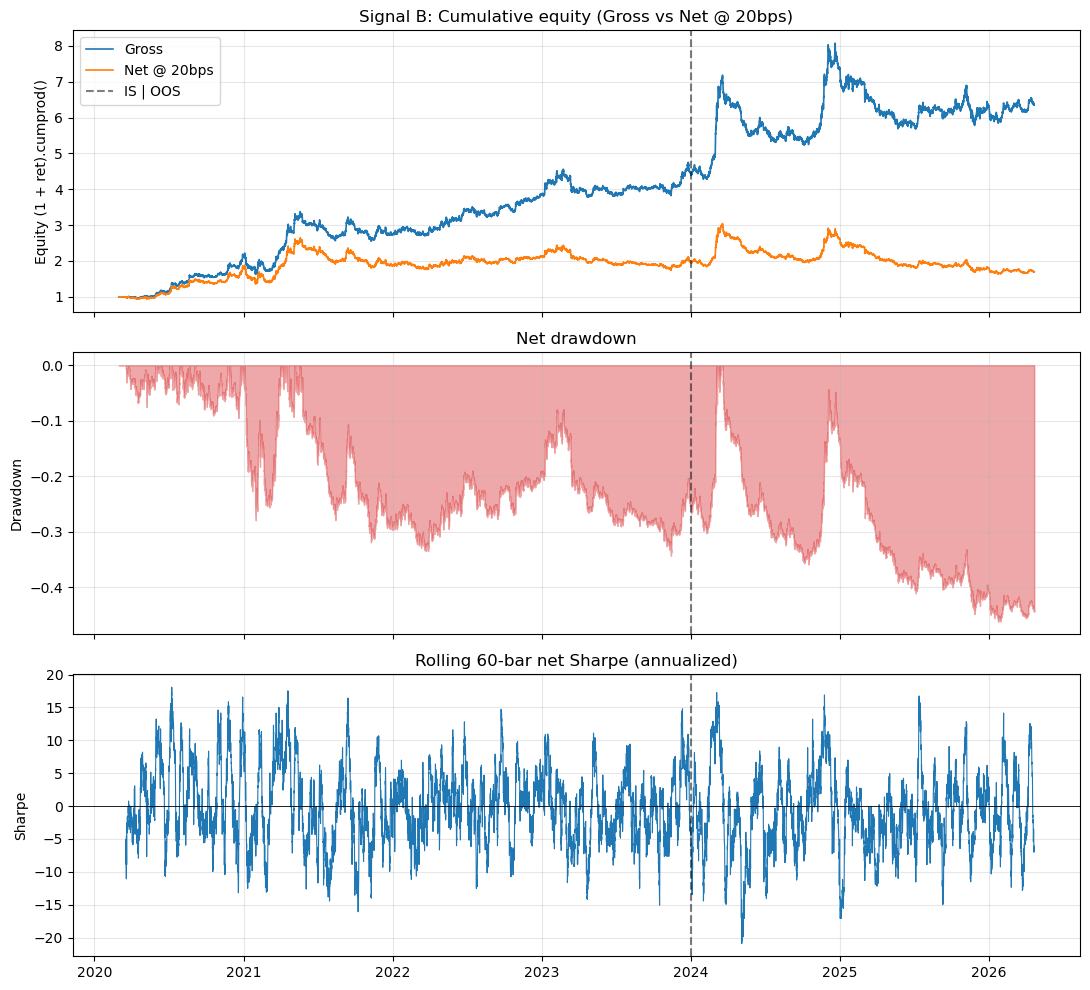

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

equity_gross = (1 + gross_full.fillna(0)).cumprod()
equity_net   = (1 + net_full.fillna(0)).cumprod()
ax = axes[0]
ax.plot(equity_gross.index, equity_gross.values, label='Gross', lw=1.2)
ax.plot(equity_net.index,   equity_net.values,   label='Net @ 20bps', lw=1.2)
ax.axvline(pd.Timestamp(OOS_START), color='k', ls='--', alpha=0.5, label='IS | OOS')
ax.set_title('Signal B: Cumulative equity (Gross vs Net @ 20bps)')
ax.set_ylabel('Equity (1 + ret).cumprod()')
ax.legend(); ax.grid(alpha=0.3)

dd_net = drawdown(equity_net)
ax = axes[1]
ax.fill_between(dd_net.index, dd_net.values, 0, color='tab:red', alpha=0.4)
ax.axvline(pd.Timestamp(OOS_START), color='k', ls='--', alpha=0.5)
ax.set_title('Net drawdown')
ax.set_ylabel('Drawdown')
ax.grid(alpha=0.3)

win = 60
rolling_sharpe = (
    net_full.rolling(win).mean() / net_full.rolling(win).std() * np.sqrt(BARS_PER_YEAR_4H)
)
ax = axes[2]
ax.plot(rolling_sharpe.index, rolling_sharpe.values, lw=0.8)
ax.axhline(0, color='k', lw=0.6)
ax.axvline(pd.Timestamp(OOS_START), color='k', ls='--', alpha=0.5)
ax.set_title(f'Rolling {win}-bar net Sharpe (annualized)')
ax.set_ylabel('Sharpe')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Conclusion

### Bar-level correlation with Signal A

| Window | Net corr | Gross corr |
|---|---|---|
| Full (13459 bars) | **−0.36** | −0.36 |
| IS (8406 bars) | **−0.32** | −0.32 |
| OOS (5053 bars) | **−0.43** | −0.43 |

At a gross Sharpe for full sample of 0.457 with a negative sharpe for OOS, this is not a great strategy on its own. However, I found that it is negatively correlated with Signal A, our reversal strategy.

Signals A and B are consistently anti-correlated at −0.3 to −0.4 across IS and OOS. This is a stable relationship across the regimes we discovered in Signal A. OOS anti-correlation is actually *stronger* than IS, which rules out the possibility that the IS result was a coincidence of sampling.

This means applied and weighted together, we are likely to hedge each strategy which *should* improve sharpe.



In [34]:
# Persist Signal B artifact for combined-portfolio work
artifact_path = os.path.join(PROJECT_DIR, 'data', 'signal_b_v1_mom42_skip1_per3day.pkl')
artifact = {
    'weights': weights_b_full,
    'gross_ret': gross_ret_b_full,
    'net_ret': net_ret_b_full,
    'turnover': turnover_b_full,
    'universe': universe,
    'universe_top20': universe_top20,
    'config': {
        'horizon_bars': H,
        'direction': 'momentum',
        'skip': 1,
        'rebalance_every_bars': REBALANCE_EVERY,
        'universe': 'top-20 by trailing 30d dvol, within monthly top-50',
        'cost_bps_assumed': 20,
        'is_start': IS_START,
        'is_end': IS_END,
        'oos_start': OOS_START,
    },
}
with open(artifact_path, 'wb') as f:
    pickle.dump(artifact, f)

print(f"Saved: {artifact_path}")


Saved: /Users/muditlam/Desktop/PythonJupyterCode/classProject/data/signal_b_v1_mom42_skip1_per3day.pkl
